In [418]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
import glob
from collections import defaultdict
import pandas as pd

In [419]:
%config InlineBackend.figure_format = 'retina'
# Or, for non-IPython environments:
plt.rcParams['figure.dpi'] = 200

In [420]:
#file/prefix definitions
root_dir = "/vision/asomaya1/active-rir/runs"
fs_rir_errors_path = "intermediate_errors_fs_rir_full.json"
active_rir_errors_path = "intermediate_errors_full.json"
tb_dir = "tb"


#Whether to display all models (False) or the average of the US and the average of the SD models (True)
display_averaged_models = False
plot_timesteps = False
N = 20
plot_clip_val = 19

In [421]:
def smooth_data(x, y, num_points=80, kind='cubic'):
    # Create a spline interpolation
    f = interp1d(x, y, kind=kind)
    # Create new x values
    x_smooth = np.linspace(x[0], x[-1], num=num_points)
    # Compute the smoothed y values
    y_smooth = f(x_smooth)
    return x_smooth, y_smooth

In [422]:
def format_all_trajectories(trajectories, n_obs):
    trajectories = [lst for lst in trajectories if len(lst) > 0]
    # Initialize a list to store the mean values for each key at each step
    mean_values = []
    #Iterate over each step (20 steps)
    for step in range(n_obs):
        step_means = {}
        # Iterate over each trajectory
        for trajectory in trajectories:
            for key, values in list(trajectory[step].items()): #NOTE: removed [:-1]
                mean = np.mean(np.array(values))
                if key not in step_means:
                    step_means[key] = []
                step_means[key].append(mean)
        
        # Append the dictionary to the mean_values list
        mean_values.append(step_means)

    return mean_values

In [423]:
#choose which run to visualize here. First run in list should have fs_rir_errors computed and stored with it.
#runs = ['SD_C_all_subg_queries', 'SD_N_all_subg_queries', 'SD_CNA_all_subg_queries', 'US_C_all_subg_queries', 'US_N_all_subg_queries','US_CNA_all_subg_queries'] # 'US_CNA_all_subg_queries' 'US_CNA_all_subg_queries_RTE_metric', 'US_CN_all_subg_queries'
runs = ['SD_CNA_v2policy']#, 'US_N_v2policy'] #'US_CN_v2policy', 'SD_CN_v2policy', 'SD_CN_v2policy',  'US_CN_v2policy', 'SD_CN_v2policy', 'SD_C_v2policy', 'SD_N_v2policy',  'US_CNA_v2policy', 'US_CN_v2policy'
fs_rirs_run = ['SD_CN_v2policy']
active_rir_errors_list = []

if display_averaged_models:
    new_model_names = ['Uniform', 'ActiveRIR']
else:
    new_model_names = ['ActiveRIR (Acoustic)', 'FS-RIR'] #, 'ActiveRIR (Exploration)', 

for run in runs:
    with open(os.path.join(root_dir, run, tb_dir, active_rir_errors_path)) as f:
        active_rir_errors = json.load(f)
        active_rir_errors_list.append(active_rir_errors)

try:
    with open(os.path.join(root_dir, fs_rirs_run[0], tb_dir, fs_rir_errors_path)) as f:
        fs_rir_errors = json.load(f)
except:
    fs_rir_errors = active_rir_errors

In [424]:
active_rir_errors_pref_list = []
episodes = [lst['episode'][1] for lst in active_rir_errors_list[0] if len(lst) > 0]
active_rir_errors = [[lst['metrics'] for lst in active_rir_errors if len(lst) > 0] for active_rir_errors in active_rir_errors_list]
timestamps = [[lst['timestamps'] for lst in active_rir_errors if len(lst) > 0] for active_rir_errors in active_rir_errors_list]
fs_rir_errors = [lst['metrics'] for lst in fs_rir_errors if len(lst) > 0]

In [425]:
#fix issue with timestamps for US models:
for idx, run in enumerate(runs):
    if "US" in run:
        timestamps[idx] = [[x - 10 for x in sublist] for sublist in timestamps[idx]]


In [426]:
n_obs = len(active_rir_errors[0][0]) #ATTN: first run in list should have all N episodes

In [427]:
active_rir_errors = [format_all_trajectories(active_rir_error,n_obs) for active_rir_error in active_rir_errors]
fs_rir_errors = format_all_trajectories(fs_rir_errors, n_obs)

In [428]:
keys_to_plot = ['stft_l1_distance']#, 'diff_rt_startFrom60dB']#, 'rel_diff_edt']

if display_averaged_models:
    us_sums = [None] * 20  # Assuming 20 observations
    sd_sums = [None] * 20  # Assuming 20 observations
    us_count = 0
    sd_count = 0
    timestamps_us = []
    timestamps_sd = []

    # Initialize sums for US and SD models
    for idx, model in enumerate(active_rir_errors):
        model_type = "US" if "US" in runs[idx] else "SD"
        if model_type == "US":
            timestamps_us.append(timestamps[idx])
        if model_type == "SD":
            timestamps_sd.append(timestamps[idx])
        for obs_idx, observation in enumerate(model):
            for metric, values in observation.items():
                if metric not in keys_to_plot:
                    continue
                # Initialize containers for sums
                if us_sums[obs_idx] is None and model_type == "US":
                    us_sums[obs_idx] = {m: [0]*len(values) for m in keys_to_plot}
                    
                if sd_sums[obs_idx] is None and model_type == "SD":
                    sd_sums[obs_idx] = {m: [0]*len(values) for m in keys_to_plot}

                # Accumulate the sum for each metric and each trajectory
                if model_type == "US":
                    for t_idx, val in enumerate(values):
                        us_sums[obs_idx][metric][t_idx] += val
                    us_count += 1  # Count the number of US models
                elif model_type == "SD":
                    for t_idx, val in enumerate(values):
                        sd_sums[obs_idx][metric][t_idx] += val
                    sd_count += 1  # Count the number of SD models

    # Compute the averages for US and SD models
    us_avg = [{metric: [val / us_count for val in values] for metric, values in observation.items()} for observation in us_sums]
    sd_avg = [{metric: [val / sd_count for val in values] for metric, values in observation.items()} for observation in sd_sums]

    # Overwrite active_rir_errors to contain only these two "averaged" models
    active_rir_errors = [us_avg, sd_avg]
    runs = ['Uniform sampling', 'Active sampling']

    timestamps_us = np.array(timestamps_us)
    avg_timestamps_us = np.mean(timestamps_us, axis=1)

    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs_us = np.diff(avg_timestamps_us, axis=1).mean(axis=1)
    new_column_us = avg_timestamps_us[:, -1] + mean_diffs_us
    padded_avg_timestamps_us = np.column_stack((avg_timestamps_us, new_column_us))

    timestamps_sd = np.array(timestamps_sd)
    avg_timestamps_sd = np.mean(timestamps_sd, axis=1)

    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs_sd = np.diff(avg_timestamps_sd, axis=1).mean(axis=1)
    new_column_sd = avg_timestamps_sd[:, -1] + mean_diffs_sd
    padded_avg_timestamps_sd = np.column_stack((avg_timestamps_sd, new_column_sd))

    padded_avg_timestamps = [np.mean(padded_avg_timestamps_us,axis=0), np.mean(padded_avg_timestamps_sd, axis=0)]

In [429]:
if not display_averaged_models:
    timestamps = np.array(timestamps)
    avg_timestamps = np.mean(timestamps, axis=1)
    #TODO: Remove this after adding in 20th observation into ppo_trainer:
    mean_diffs = np.diff(avg_timestamps, axis=1).mean(axis=1)
    new_column = avg_timestamps[:, -1] + mean_diffs
    padded_avg_timestamps = np.column_stack((avg_timestamps, new_column))

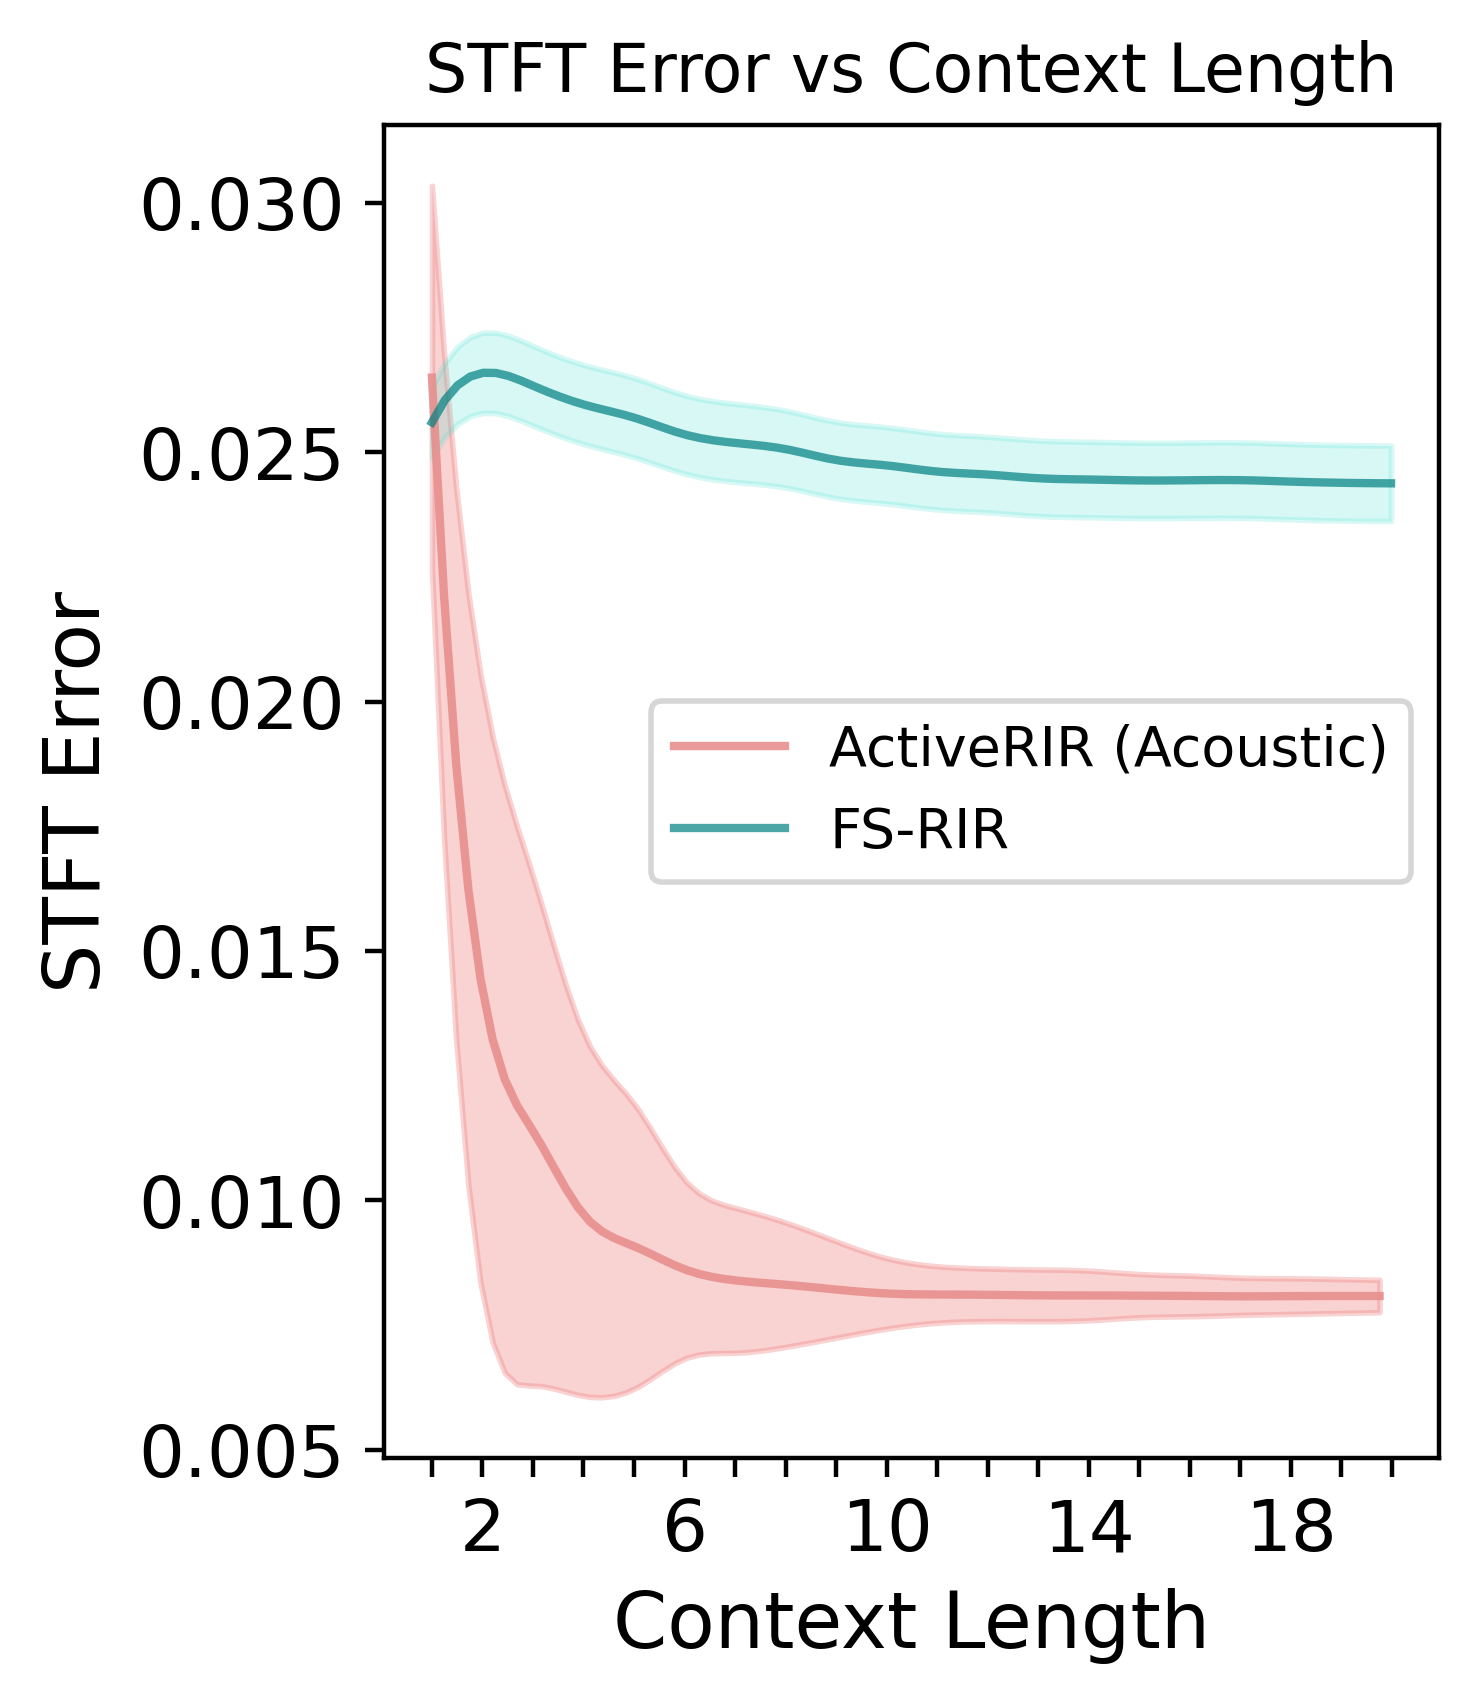

In [430]:
key_short_names = ['STFT Error', 'RTE', 'EDT', 'DRRE', 'Relative RTE']
colors_line = ['green', 'blue', 'red', 'orange', 'pink', 'purple', 'springgreen', 'cyan']
colors_err = ['lightcoral', 'lightgreen', 'lightskyblue', 'khaki', 'plum', 'mistyrose', 'aquamarine', 'mediumturquoise']
colors_line = ['#E78F8E', '#41729F', 'dodgerblue', 'darkorange', 'darkviolet', 'red'] #['#E78F8E', '#88D498']

#colors_line = ['slategray', 'darkolivegreen']
#colors_err = ['lightslategray', 'yellowgreen']

fs_rir_mean_metric_stats = {}

# Create subplots for each key
fig, axes = plt.subplots(1,len(keys_to_plot), figsize=(6, 5), squeeze=False)
#fig.tight_layout(pad=4.0)
fig.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0, rect=[0, 0, 0.75, 1])
legend_labels = []

# Iterate through the keys and plot each one
for i, key in enumerate(keys_to_plot):
    row, col = divmod(i, 2)

    # Extract the values for the current key from all dictionaries
    values_active = []
    for active_rir_error in active_rir_errors:
        values_active.append(np.array([np.array(entry[key]) for entry in active_rir_error]))
    values_fsrir = np.array([np.array(entry[key]) for entry in fs_rir_errors])

    # Calculate the mean values and standard deviations at each position
    mean_active_values = []
    std_active_values = []
    for val_idx, value_active in enumerate(values_active):
        mean_active_values.append(np.mean(value_active, axis=-1))
        std_active_values.append(np.std(value_active, axis=-1)*1)# / np.sqrt(len(value_active[0])))

    mean_fsrir_values = np.mean(values_fsrir, axis=-1)
    std_fsrir_values = np.std(values_fsrir, axis=-1)  / np.sqrt(len(values_fsrir[0]))
    fs_rir_mean_metric_stats[key] = mean_fsrir_values[-1]

    # Create the fs_rir x-axis (positions):
    positions_fs_rir = np.linspace(0, N, 20, dtype=int)
    positions_obs = range(20) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

    if not plot_timesteps:
        padded_avg_timestamps = [np.array(positions_obs) for run in padded_avg_timestamps]

    x_positions_smooth, mean_active_values_smooth = zip(*[smooth_data(positions, vals) for positions, vals in zip(padded_avg_timestamps, mean_active_values)])
    _, std_active_values_smooth = zip(*[smooth_data(positions, vals) for positions, vals in zip(padded_avg_timestamps, std_active_values)])
    x_positions_smooth_fsrir, mean_fsrir_values_smooth = smooth_data(positions_fs_rir, mean_fsrir_values)
    _, std_fsrir_values_smooth = smooth_data(positions_fs_rir, std_fsrir_values)

    plt.rcParams.update({'font.size': 10, 'axes.labelsize': 14, 'xtick.labelsize': 13, 'ytick.labelsize': 13})
    # Plot the mean line (smoothed)
    active_lines = {}
    for idx, vals in enumerate(mean_active_values_smooth):
        #print(x_positions_smooth[idx])
        active_lines[idx], = axes[row, col].plot(x_positions_smooth[idx][x_positions_smooth[idx]< plot_clip_val], vals[x_positions_smooth[idx]< plot_clip_val], label=f'ActiveRIR (ours)', color=colors_line[idx], alpha=0.9)
    fsrir_line, = axes[row, col].plot(x_positions_smooth_fsrir[x_positions_smooth_fsrir< plot_clip_val], mean_fsrir_values_smooth[x_positions_smooth_fsrir< plot_clip_val], label=f'FS-RIR', color='teal', alpha=0.7)
    

    # Plot the standard deviation as shaded area (smoothed)
    for idx in range(len(mean_active_values_smooth)):
        axes[row, col].fill_between(x_positions_smooth[idx][x_positions_smooth[idx]< plot_clip_val], (mean_active_values_smooth[idx] - std_active_values_smooth[idx])[x_positions_smooth[idx]< plot_clip_val], (mean_active_values_smooth[idx] + std_active_values_smooth[idx])[x_positions_smooth[idx]< plot_clip_val], alpha=0.35, color=colors_err[idx])
    axes[row, col].fill_between(x_positions_smooth_fsrir[x_positions_smooth_fsrir< plot_clip_val], (mean_fsrir_values_smooth - std_fsrir_values_smooth)[x_positions_smooth_fsrir< plot_clip_val], (mean_fsrir_values_smooth + std_fsrir_values_smooth)[x_positions_smooth_fsrir< plot_clip_val], alpha=0.2, color='turquoise')

    # Customize plot
    if not plot_timesteps:
        axes[row, col].set_title(f'{key_short_names[i]}' + " vs Context Length")
        axes[row, col].set_xlabel('Context Length')
    else:
        axes[row, col].set_title(f'{key_short_names[i]}' + " vs Trajectory Length")
        axes[row, col].set_xlabel('Timesteps')
    axes[row, col].set_ylabel(f'{key_short_names[i]}')
    #axes[i].legend()

    # Set x-axis ticks to integers
    if not plot_timesteps:
        axes[row, col].set_xticks(positions_obs)
    else:
        axes[row, col].set_xticks(positions_fs_rir[positions_fs_rir< plot_clip_val])
    axes[row, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers

for idx, run in enumerate(runs):
    legend_labels.append((active_lines[idx], new_model_names[idx]))
legend_labels.append((fsrir_line, "FS-RIR"))

if len(keys_to_plot) % 2 != 0:
    axes[row, col].legend(*zip(*legend_labels), loc='center right')#, bbox_to_anchor=(1, 1))

N = 4  # Interval of ticks to display
ticks = axes[row, col].get_xticks()
tick_labels = [1+label if i % N == 1 else '' for i, label in enumerate(ticks)]
axes[row, col].set_xticklabels(tick_labels)

#plt.suptitle('Metrics vs Context Length ')
#plt.subplots_adjust(right=1.0)
plt.show()

fig.savefig('/vision/asomaya1/active-rir/scripts/eval_stats_aggregation/fs_rir_trajectories.png', dpi=1200)  # Save the plot with higher DPI

In [363]:
# Number of models
num_models = len(active_rir_errors)
# Number of observations (positions) for each model
num_positions = len(active_rir_errors[0])  # Assuming all models have the same number of positions
# Number of trajectories might vary for each model and metric
# But you can still define the maximum number of trajectories to create the subplots
max_num_trajectories = max(len(model[0][list(model[0].keys())[0]]) for model in active_rir_errors)
fs_rir_errors_per_trajectory = defaultdict(list)
active_rir_errors_per_trajectory = [defaultdict(list) for _ in range(len(active_rir_errors))]
#for key in keys_to_plot:
#    fs_rir_errors_per_trajectory[key] = []

# Create subplots for the maximum number of trajectories and each key
fig, axes = plt.subplots(max_num_trajectories, min(len(keys_to_plot[:3])*2,3), figsize=(30, max_num_trajectories * min(len(keys_to_plot)*2,3)))  # Adjust figsize as needed
#fig.tight_layout(pad=4.0)

# Ensure axes is always a 2D array (needed for a single row of subplots)
if max_num_trajectories == 1:
    axes = [axes]

# Iterate through each trajectory
for traj_idx in range(max_num_trajectories):
    for i, key in enumerate(keys_to_plot[:3]):
        row, col = traj_idx, i

        # Create the x-axis (positions)
        positions = range(num_positions)

        # Iterate through each model
        for model_idx, model in enumerate(active_rir_errors):
            # Check if the trajectory exists for the current model
            if traj_idx < len(model[0][list(model[0].keys())[0]]):
                # Extract the values for the current key for the current trajectory for each position
                values_active = [model[pos][key][traj_idx] for pos in range(num_positions)]
                active_rir_errors_per_trajectory[model_idx][key].append(values_active[-1])

                smoothed_positions, smoothed_values_active = smooth_data(padded_avg_timestamps[model_idx], values_active)
                
                # Plot the line for the current model
                axes[row, col].plot(smoothed_positions, smoothed_values_active, label=f'Model {model_idx+1}', color=colors_line[model_idx], alpha=0.7)

        values_fsrir = [fs_rir_errors[pos][key][traj_idx] for pos in range(num_positions)]
        fs_rir_errors_per_trajectory[key].append(values_fsrir[-1])
        #smoothed_positions, smoothed_values_fsrir = smooth_data(positions_fs_rir, values_fsrir)
        #axes[row, col].plot(smoothed_positions, smoothed_values_fsrir, label='FS-RIR', color='gray', alpha=0.7)

        # Customize plot for the trajectory if it exists
        if any(traj_idx < len(model[0][list(model[0].keys())[0]]) for model in active_rir_errors):
            axes[row, col].set_title(f'Trajectory {episodes[traj_idx]} - {key_short_names[i]}')
            axes[row, col].set_xlabel('Context Length')
            axes[row, col].set_ylabel(f'{key_short_names[i]}')
            if not plot_timesteps:
                axes[row, col].set_xticks(positions_obs)
            else:
                axes[row, col].set_xticks(positions_fs_rir)
            axes[row, col].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers
            if traj_idx == max_num_trajectories - 1 and i == 0:
                axes[row, col].legend(*zip(*legend_labels), loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=num_models)  # adjust ncol as needed
        else:
            # Clear the subplot if no trajectory exists for this index
            axes[row, col].axis('off')

plt.show()

ValueError: Image size of 12000x180000 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 6000x90000 with 450 Axes>

## Graphs

In [ ]:
display_with_fs_rir = True

In [ ]:
# Initial setup
episodes_data = []
keys_to_plot_ep_data = keys_to_plot#['stft_l1_distance', 'diff_rt_startFrom60dB', 'rel_diff_edt']

# Loop over each episode
for idx in range(max_num_trajectories):
    ep_data = {}
    
    if display_with_fs_rir:
    # Process fs_rir_errors_per_trajectory first
        fs_rir_ep_data = {key: fs_rir_errors_per_trajectory[key][idx] for key in keys_to_plot_ep_data}
        for key_idx, key in enumerate(keys_to_plot_ep_data):
            ep_data[('FS-RIR', key_short_names[key_idx])] = fs_rir_ep_data[key]
    
    # Now process each object in active_rir_errors_per_trajectory
    for obj_idx, obj_data in enumerate(active_rir_errors_per_trajectory):
        active_rir_ep_data = {key: obj_data[key][idx] for key in keys_to_plot_ep_data}
        for key_idx, key in enumerate(keys_to_plot_ep_data):
            ep_data[(runs[obj_idx], key_short_names[key_idx])] = active_rir_ep_data[key]
    
    # Add episode number to the data
    ep_data['Episode ID'] = episodes[idx]
    episodes_data.append(ep_data)

# Convert to DataFrame and handle multi-level columns
episodes_df = pd.DataFrame(episodes_data).set_index('Episode ID')
episodes_df.columns = pd.MultiIndex.from_tuples(episodes_df.columns, names=['Model', 'Metric'])

In [ ]:
# Construct the full directory path
video_dir = "video_dir"
video_dir_path = os.path.join(root_dir, fs_rirs_run[0], video_dir)

# Dictionary to hold the mapping from episode ID to scene name
episode_to_scene = {}

# List all mp4 files in the directory
for filename in glob.glob(os.path.join(video_dir_path, '*.mp4')):
    # Extract scene name and episode ID from the filename
    parts = os.path.basename(filename).split('_')
    if len(parts) >= 2:
        scene_name = parts[0]
        try:
            episode_id = int(parts[1])
            # Update the dictionary with the mapping
            # This will overwrite the scene name for an episode ID if it already exists
            episode_to_scene[episode_id] = scene_name
        except ValueError:
            print(f"Skipping file due to unexpected format: {filename}")

In [ ]:
# Map each episode ID to its scene name using the 'episode_to_scene' dictionary
episodes_df['Scene Name'] = episodes_df.index.map(lambda x: episode_to_scene[int(x)])

# Group by 'Scene Name' and calculate mean
mean_df = episodes_df.groupby('Scene Name').mean()

In [ ]:
episodes_df['FS-RIR'].mean()

In [ ]:
episodes_df['SD_CNA_v2policy'].mean()

In [ ]:
mean_df

In [ ]:
y_limits = {'STFT Error': (0.007, 2), 'RTE': None, 'EDT': None}  # Example limits

# Example plot for 'STFT Error' across all models for each scene
metrics = ['STFT Error', 'RTE', 'EDT'][:len(keys_to_plot)]  # Define all metrics you want to plot
colors = ['red', 'green', 'blue', 'orange', 'purple']
colors = ['#E78F8E', '#41729F', '#88D498', '#ECD078', '#D8A6BF', '#79A3B1']
if display_averaged_models:
    new_model_names = ['Uniform', 'ActiveRIR']
else:
    new_model_names = ['ActiveRIR (Acoustic)', 'ActiveRIR (Exploration)', 'Uniform (Acoustic)', 'Uniform (Exploration)']

for metric in metrics:
    # Filter columns for the current metric
    metric_cols = [col for col in mean_df.columns if metric in col]
    metric_df = mean_df[metric_cols]
    labels = new_model_names[:len(metric_cols)]
    
    # Plotting
    metric_df.plot(kind='bar', figsize=(12, 6), color=colors)
    plt.title(f'{metric} by Scene')
    plt.ylabel(metric)
    plt.xlabel('Scene Name')
    plt.xticks(rotation=45)
    plt.legend(labels=labels)#[col[0] for col in metric_cols])
    plt.tight_layout()

    if y_limits[metric]:
        plt.ylim(y_limits[metric])  # Set the y-axis limits if specified

    plt.show()